# Signal Processing and Time Series Forecasting

This notebook demonstrates two powerful Endgame modules using **real data**:

1. **Signal Processing** (`endgame.signal`) -- ECG recording from the MIT-BIH Arrhythmia Database (108,000 samples)
2. **Time Series Forecasting** (`endgame.timeseries`) -- Electricity Transformer Temperature dataset (17,420 hourly observations)

Both modules follow the sklearn-compatible API (`fit` / `transform` / `predict`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Consistent plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
np.random.seed(42)

---
## Part 1: Signal Processing with Real ECG Data

We use a **real electrocardiogram (ECG)** recording from the **MIT-BIH Arrhythmia
Database** (record 208), available via `scipy.datasets.electrocardiogram()`.
This is 5 minutes of single-lead ECG sampled at 360 Hz from an actual patient
with ventricular arrhythmia.

ECG signals contain characteristic frequency components:

| Component | Frequency | Clinical Meaning |
|-----------|-----------|------------------|
| Baseline wander | < 0.5 Hz | Respiration, electrode movement |
| P/T waves | 0.5-5 Hz | Atrial/ventricular repolarization |
| **QRS complex** | **5-25 Hz** | **Ventricular depolarization (heartbeat)** |
| Muscle noise | > 40 Hz | EMG artifacts, powerline interference |

In [2]:
from scipy.datasets import electrocardiogram

ecg = electrocardiogram()  # MIT-BIH Arrhythmia Database, record 208
fs = 360  # Sampling rate in Hz
t = np.arange(len(ecg)) / fs

print(f"ECG signal: {len(ecg):,} samples at {fs} Hz")
print(f"Duration: {len(ecg)/fs:.0f}s ({len(ecg)/fs/60:.0f} min)")
print(f"Amplitude: {ecg.min():.2f} to {ecg.max():.2f} mV")

ECG signal: 108,000 samples at 360 Hz
Duration: 300s (5 min)
Amplitude: -3.48 to 3.65 mV


/tmp/ipykernel_1383086/3892065485.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


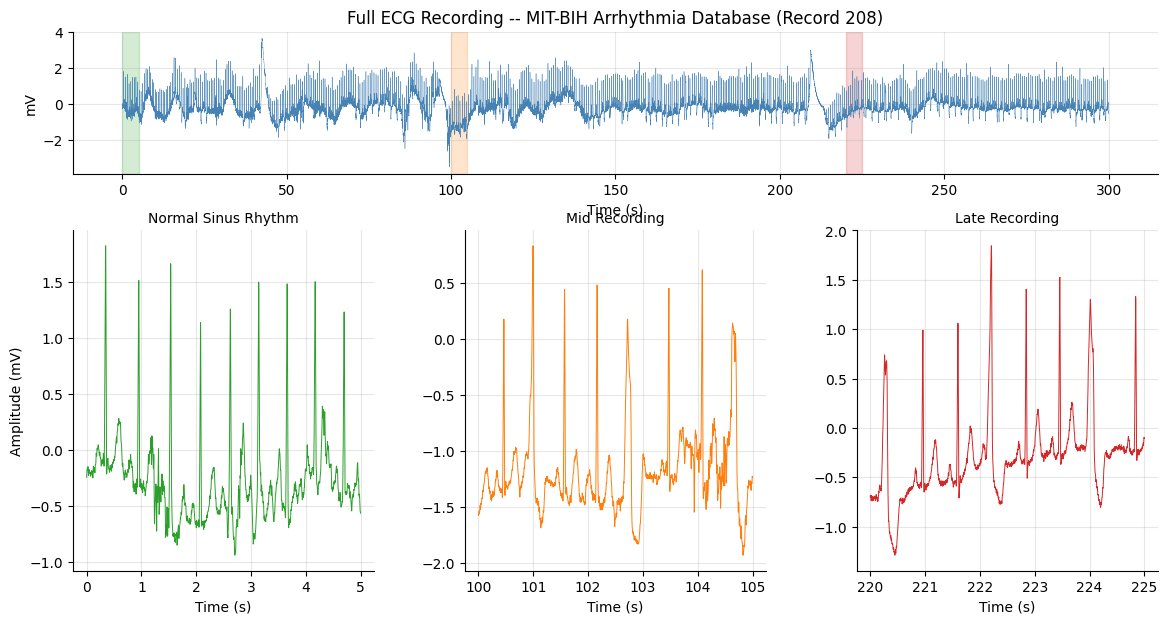

In [3]:
# Overview: full 5-minute recording with 3 zoomed windows
fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# Full signal across the top
ax_full = fig.add_subplot(gs[0, :])
ax_full.plot(t, ecg, linewidth=0.3, color="steelblue")
ax_full.set_ylabel("mV")
ax_full.set_xlabel("Time (s)")
ax_full.set_title("Full ECG Recording -- MIT-BIH Arrhythmia Database (Record 208)", fontsize=12)

# Highlight 3 windows
windows = [(0, 5, "Normal Sinus Rhythm"), (100, 105, "Mid Recording"), (220, 225, "Late Recording")]
colors = ["tab:green", "tab:orange", "tab:red"]
for (ws, we, _), c in zip(windows, colors):
    ax_full.axvspan(ws, we, alpha=0.2, color=c)

# Zoomed panels
for i, ((ws, we, label), color) in enumerate(zip(windows, colors)):
    ax = fig.add_subplot(gs[1:, i])
    mask = (t >= ws) & (t < we)
    ax.plot(t[mask], ecg[mask], linewidth=0.7, color=color)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Time (s)")
    if i == 0:
        ax.set_ylabel("Amplitude (mV)")

plt.suptitle("", fontsize=1)  # tight_layout workaround
plt.tight_layout()
plt.show()

### 1.2 Butterworth Bandpass Filter

A standard clinical ECG bandpass is **0.5-40 Hz**:
- Highpass at 0.5 Hz removes baseline wander
- Lowpass at 40 Hz removes muscle noise and powerline interference

We also extract the **QRS band (5-15 Hz)** to isolate heartbeat spikes.

In [4]:
from endgame.signal import ButterworthFilter

# Clinical ECG bandpass: 0.5-40 Hz
bp_filter = ButterworthFilter(lowcut=0.5, highcut=40, fs=fs, order=4)
ecg_filtered = bp_filter.fit_transform(ecg.reshape(1, -1)).ravel()

# QRS isolation: 5-15 Hz (Pan-Tompkins preprocessing)
qrs_filter = ButterworthFilter(lowcut=5, highcut=15, fs=fs, order=4)
ecg_qrs = qrs_filter.fit_transform(ecg.reshape(1, -1)).ravel()

print(f"Bandpass filter: 0.5-40 Hz, order 4")
print(f"QRS filter: 5-15 Hz, order 4")

Bandpass filter: 0.5-40 Hz, order 4
QRS filter: 5-15 Hz, order 4


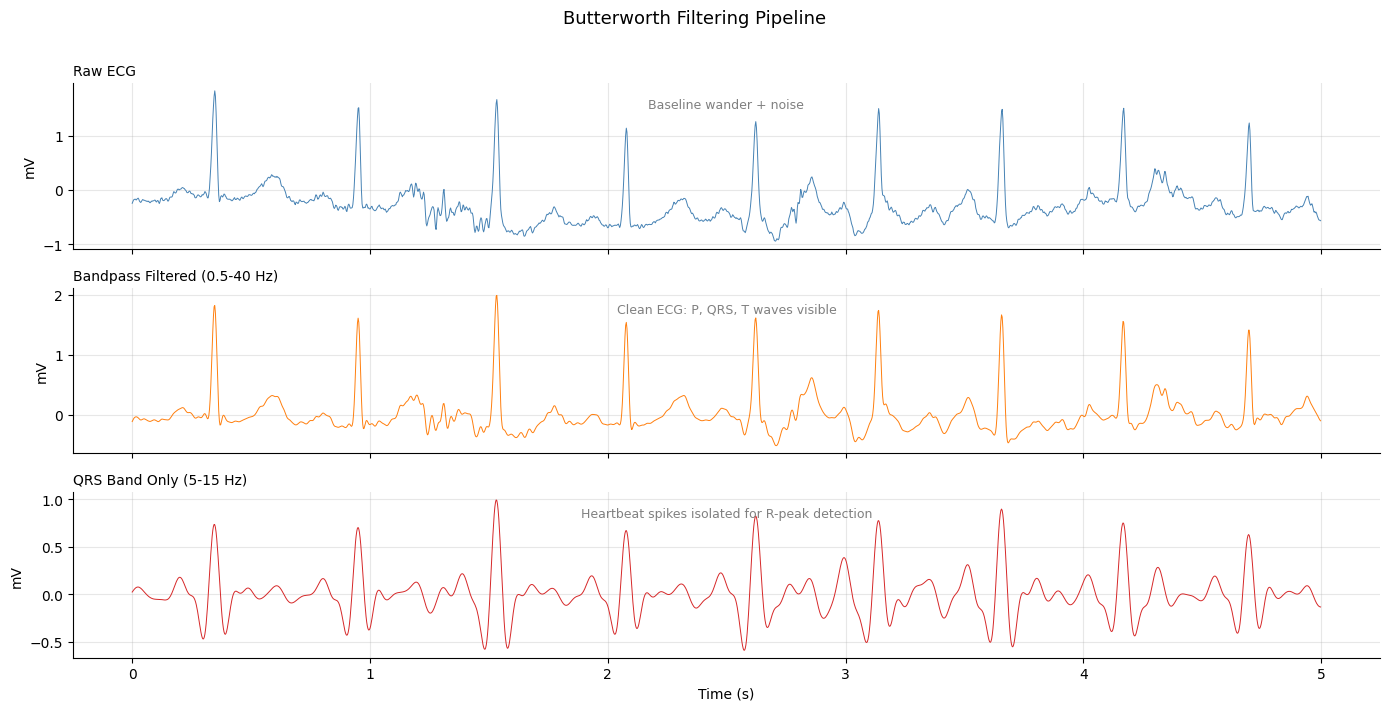

In [5]:
# 3-panel comparison: raw, filtered, QRS-isolated
seg = slice(0, 5 * fs)  # 5 seconds

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

axes[0].plot(t[seg], ecg[seg], linewidth=0.7, color="steelblue")
axes[0].set_ylabel("mV")
axes[0].set_title("Raw ECG", loc="left", fontsize=10)
axes[0].annotate("Baseline wander + noise", xy=(0.5, 0.85), xycoords="axes fraction",
                 fontsize=9, color="gray", ha="center")

axes[1].plot(t[seg], ecg_filtered[seg], linewidth=0.7, color="tab:orange")
axes[1].set_ylabel("mV")
axes[1].set_title("Bandpass Filtered (0.5-40 Hz)", loc="left", fontsize=10)
axes[1].annotate("Clean ECG: P, QRS, T waves visible", xy=(0.5, 0.85),
                 xycoords="axes fraction", fontsize=9, color="gray", ha="center")

axes[2].plot(t[seg], ecg_qrs[seg], linewidth=0.7, color="tab:red")
axes[2].set_ylabel("mV")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("QRS Band Only (5-15 Hz)", loc="left", fontsize=10)
axes[2].annotate("Heartbeat spikes isolated for R-peak detection", xy=(0.5, 0.85),
                 xycoords="axes fraction", fontsize=9, color="gray", ha="center")

plt.suptitle("Butterworth Filtering Pipeline", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 1.3 Spectral Analysis with FFTTransformer

The FFT reveals frequency content: heart rate harmonics, noise sources,
and the effect of filtering.

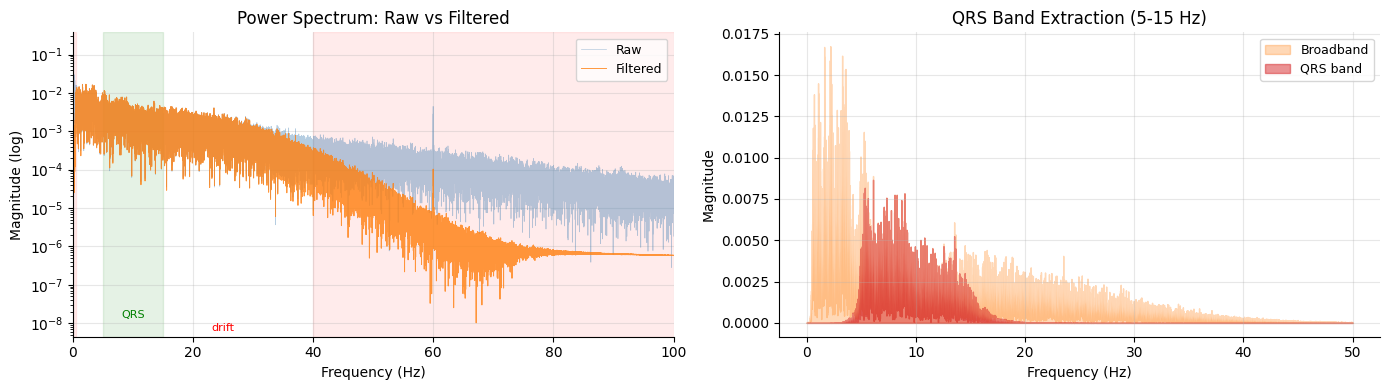

In [6]:
from endgame.signal import FFTTransformer

fft_trans = FFTTransformer(fs=fs, output="magnitude")
spectrum_raw = fft_trans.fit_transform(ecg.reshape(1, -1))
freqs = fft_trans.freqs_
spectrum_filt = fft_trans.fit_transform(ecg_filtered.reshape(1, -1))
spectrum_qrs = fft_trans.fit_transform(ecg_qrs.reshape(1, -1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: log-scale comparison
ax = axes[0]
ax.semilogy(freqs, spectrum_raw.ravel(), alpha=0.4, label="Raw", linewidth=0.5, color="steelblue")
ax.semilogy(freqs, spectrum_filt.ravel(), alpha=0.8, label="Filtered", linewidth=0.7, color="tab:orange")
ax.axvspan(0, 0.5, alpha=0.08, color="red")
ax.axvspan(40, 180, alpha=0.08, color="red")
ax.axvspan(5, 15, alpha=0.1, color="green")
ax.set_xlim(0, 100)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (log)")
ax.set_title("Power Spectrum: Raw vs Filtered")
ax.legend(fontsize=9)
ax.text(0.25, 0.02, "drift", transform=ax.transAxes, fontsize=8, color="red", ha="center")
ax.text(10, ax.get_ylim()[0] * 3, "QRS", fontsize=8, color="green", ha="center")

# Right: linear scale focused on QRS band
ax = axes[1]
mask = (freqs >= 0) & (freqs <= 50)
ax.fill_between(freqs[mask], spectrum_filt.ravel()[mask], alpha=0.3, color="tab:orange", label="Broadband")
ax.fill_between(freqs[mask], spectrum_qrs.ravel()[mask], alpha=0.5, color="tab:red", label="QRS band")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude")
ax.set_title("QRS Band Extraction (5-15 Hz)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 1.4 Wavelet Transform (CWT)

The CWT gives a **time-frequency** view: each heartbeat appears as a localized
burst of energy in the 5-15 Hz range. This is essential for detecting abnormal
beats in arrhythmia analysis.

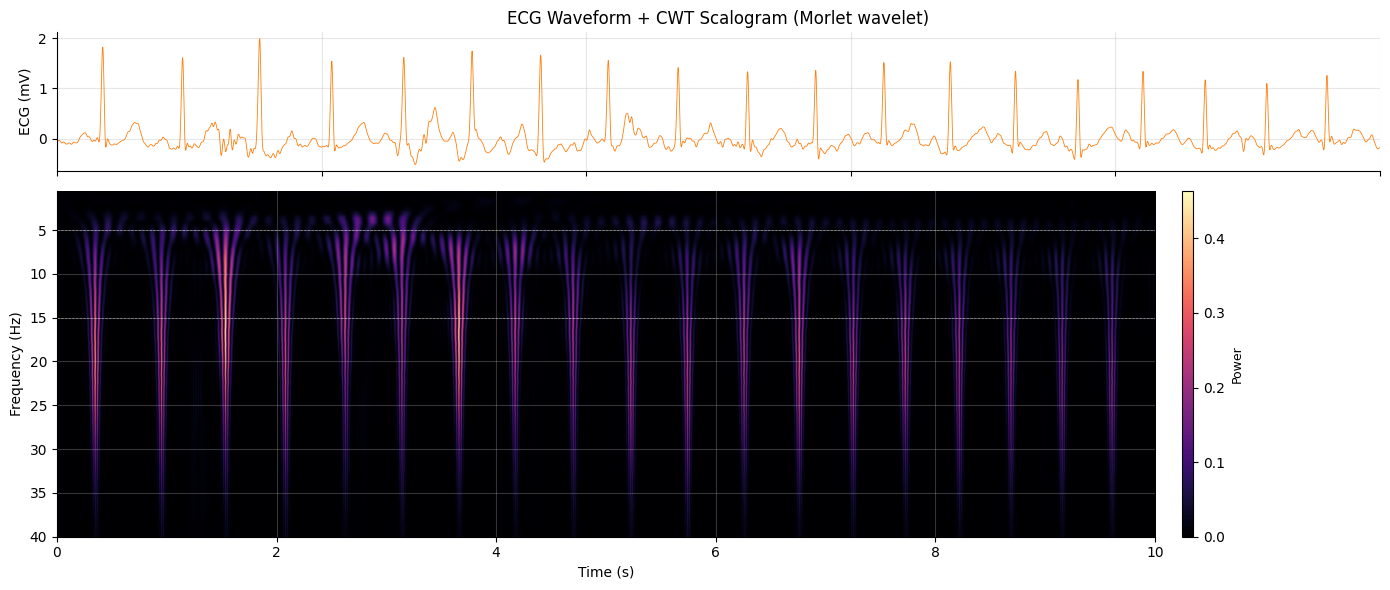

In [7]:
try:
    from endgame.signal import CWTTransformer

    # 10 seconds of filtered ECG
    n_sec = 10
    segment = ecg_filtered[:n_sec * fs].reshape(1, -1)
    t_seg = np.arange(segment.shape[1]) / fs

    cwt = CWTTransformer(fs=fs, wavelet="morl", freqs=np.linspace(0.5, 40, 80), output="power")
    tfr = cwt.fit_transform(segment)
    img = tfr.squeeze() if tfr.ndim == 3 else tfr

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), gridspec_kw={"height_ratios": [1, 2.5]},
                             sharex=True)

    # ECG trace
    axes[0].plot(t_seg, segment.ravel(), linewidth=0.6, color="tab:orange")
    axes[0].set_ylabel("ECG (mV)")
    axes[0].set_title("ECG Waveform + CWT Scalogram (Morlet wavelet)", fontsize=12)

    # Scalogram
    im = axes[1].imshow(img, aspect="auto", extent=[0, n_sec, cwt.freqs_[-1], cwt.freqs_[0]],
                        cmap="magma", interpolation="bilinear")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Frequency (Hz)")
    cbar = plt.colorbar(im, ax=axes[1], pad=0.02, aspect=30)
    cbar.set_label("Power", fontsize=9)

    # Annotate QRS band
    axes[1].axhline(y=5, color="white", linewidth=0.5, linestyle="--", alpha=0.5)
    axes[1].axhline(y=15, color="white", linewidth=0.5, linestyle="--", alpha=0.5)
    axes[1].text(n_sec + 0.15, 10, "QRS", fontsize=8, color="white", va="center")

    plt.tight_layout()
    plt.show()

except ImportError:
    print("PyWavelets not installed. Skipping CWT. Install: pip install PyWavelets")

### 1.5 Entropy and Complexity Features

Entropy and complexity measures quantify signal regularity -- critical for
distinguishing normal sinus rhythm from arrhythmia. We track these features
across sliding windows to see how the signal character changes over time.

In [8]:
from endgame.signal import PermutationEntropy, HiguchiFD

# 30-second sliding windows
win_sec = 30
win_size = win_sec * fs
n_wins = len(ecg_filtered) // win_size

pe = PermutationEntropy()
hfd = HiguchiFD()

pe_vals, hfd_vals, rms_vals = [], [], []
for i in range(n_wins):
    seg = ecg_filtered[i * win_size:(i + 1) * win_size].reshape(1, -1)
    pe_vals.append(pe.fit_transform(seg).ravel()[0])
    hfd_vals.append(hfd.fit_transform(seg).ravel()[0])
    rms_vals.append(np.sqrt(np.mean(seg ** 2)))

win_centers = [(i * win_sec + win_sec / 2) for i in range(n_wins)]

print(f"Computed {n_wins} x {win_sec}s windows")
print(f"{'Window':<6} {'Time':>10} {'PE':>10} {'HFD':>10} {'RMS':>10}")
print("-" * 48)
for i in range(n_wins):
    print(f"{i:<6} {i*win_sec:>4}-{(i+1)*win_sec:<5} {pe_vals[i]:>10.4f} {hfd_vals[i]:>10.4f} {rms_vals[i]:>10.4f}")

Computed 10 x 30s windows
Window       Time         PE        HFD        RMS
------------------------------------------------
0         0-30        0.4782     1.1535     0.3494
1        30-60        0.4738     1.1432     0.3882
2        60-90        0.4846     1.1432     0.3933
3        90-120       0.4858     1.1495     0.4113
4       120-150       0.4884     1.1576     0.3632
5       150-180       0.4767     1.1180     0.4236
6       180-210       0.4813     1.1439     0.3917
7       210-240       0.4688     1.1056     0.3506
8       240-270       0.4657     1.0994     0.4124
9       270-300       0.4705     1.1098     0.4113


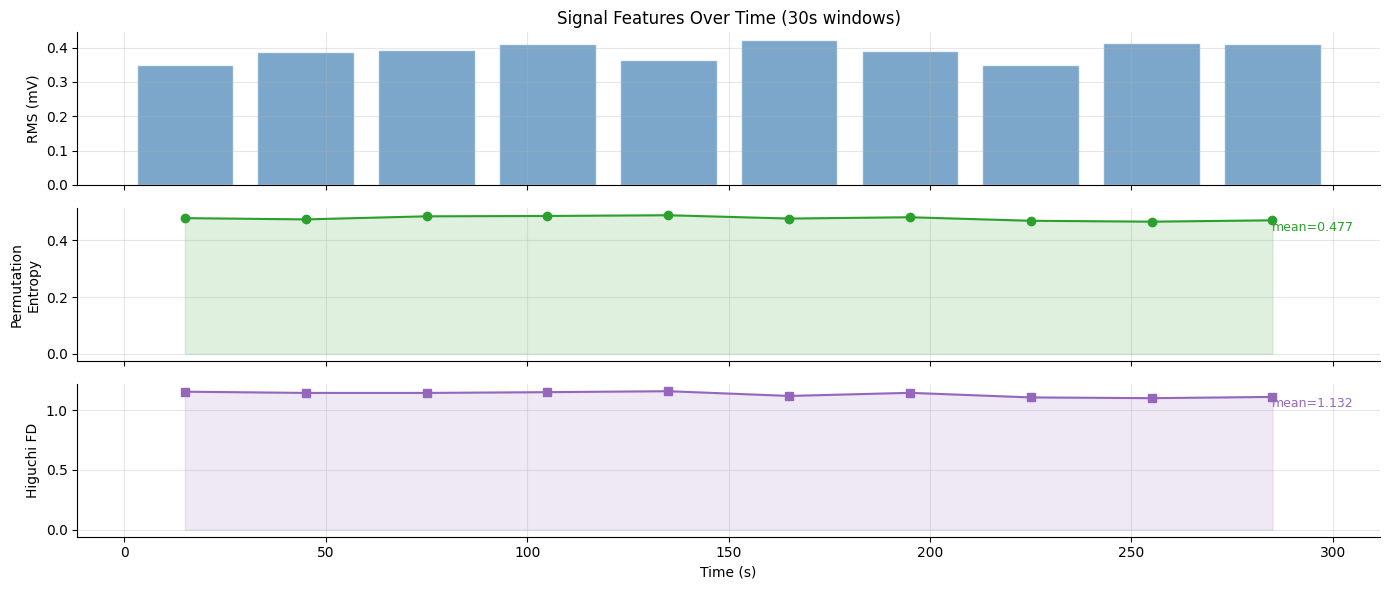

In [9]:
# Multi-feature dashboard
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)

axes[0].bar(win_centers, rms_vals, width=win_sec * 0.8, color="steelblue", alpha=0.7, edgecolor="white")
axes[0].set_ylabel("RMS (mV)")
axes[0].set_title("Signal Features Over Time (30s windows)", fontsize=12)

axes[1].plot(win_centers, pe_vals, "o-", markersize=6, color="tab:green", linewidth=1.5)
axes[1].fill_between(win_centers, pe_vals, alpha=0.15, color="tab:green")
axes[1].set_ylabel("Permutation\nEntropy")
axes[1].annotate(f"mean={np.mean(pe_vals):.3f}", xy=(0.98, 0.85), xycoords="axes fraction",
                 fontsize=9, ha="right", color="tab:green")

axes[2].plot(win_centers, hfd_vals, "s-", markersize=6, color="tab:purple", linewidth=1.5)
axes[2].fill_between(win_centers, hfd_vals, alpha=0.15, color="tab:purple")
axes[2].set_ylabel("Higuchi FD")
axes[2].set_xlabel("Time (s)")
axes[2].annotate(f"mean={np.mean(hfd_vals):.3f}", xy=(0.98, 0.85), xycoords="axes fraction",
                 fontsize=9, ha="right", color="tab:purple")

plt.tight_layout()
plt.show()

---
## Part 2: Time Series Forecasting

We use the **ETTh1** (Electricity Transformer Temperature) dataset -- a real-world
benchmark with **17,420 hourly observations** of oil temperature from an electricity
transformer in China (Jul 2016 - Jun 2018). We aggregate to daily resolution
for a 726-day forecasting task.

All Endgame forecasters follow: `fit(y)` then `predict(horizon=h)`.

In [10]:
from darts.datasets import ETTh1Dataset

ts = ETTh1Dataset().load()
y_hourly = ts["OT"].values().flatten()
hourly_dates = pd.date_range(start=ts.start_time(), periods=len(y_hourly), freq="h")

# Daily aggregation for cleaner forecasting demo
daily_series = pd.Series(y_hourly, index=hourly_dates).resample("D").mean()
y_all = daily_series.values
dates_all = daily_series.index

print(f"ETTh1 dataset: {len(y_hourly):,} hourly -> {len(y_all)} daily observations")
print(f"Date range: {dates_all[0].strftime('%Y-%m-%d')} to {dates_all[-1].strftime('%Y-%m-%d')}")
print(f"Temperature range: {y_all.min():.1f} to {y_all.max():.1f} C")

ETTh1 dataset: 17,420 hourly -> 726 daily observations
Date range: 2016-07-01 to 2018-06-26
Temperature range: -2.3 to 41.4 C


In [11]:
# Hold out last 30 days
horizon = 30
y_train = y_all[:-horizon]
y_test = y_all[-horizon:]
dates_train = dates_all[:-horizon]
dates_test = dates_all[-horizon:]

print(f"Train: {len(y_train)} days, Test: {len(y_test)} days")

Train: 696 days, Test: 30 days


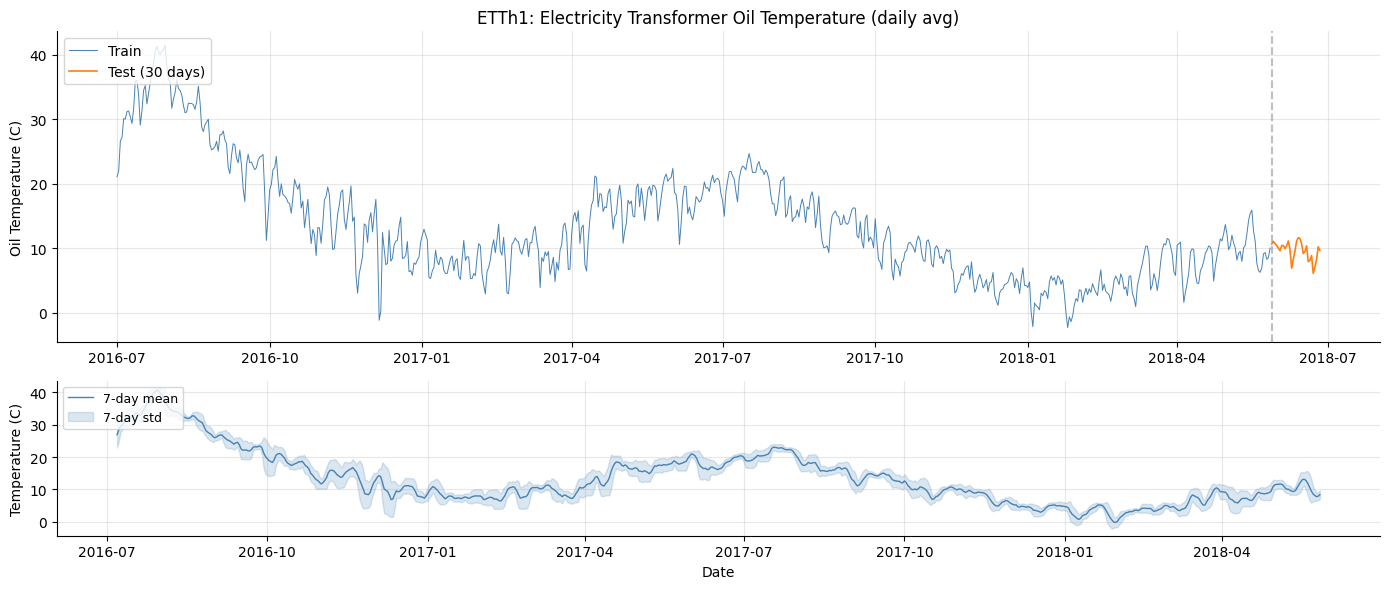

In [12]:
# Dataset overview: full series + seasonal decomposition
fig, axes = plt.subplots(2, 1, figsize=(14, 6), gridspec_kw={"height_ratios": [2, 1]})

# Full series with train/test split
ax = axes[0]
ax.plot(dates_train, y_train, linewidth=0.7, color="steelblue", label="Train")
ax.plot(dates_test, y_test, linewidth=1.2, color="tab:orange", label="Test (30 days)")
ax.axvline(x=dates_test[0], color="gray", linestyle="--", alpha=0.5)
ax.set_ylabel("Oil Temperature (C)")
ax.set_title("ETTh1: Electricity Transformer Oil Temperature (daily avg)", fontsize=12)
ax.legend(loc="upper left")

# 7-day rolling stats to show weekly pattern
ax = axes[1]
rolling_mean = pd.Series(y_train, index=dates_train).rolling(7).mean()
rolling_std = pd.Series(y_train, index=dates_train).rolling(7).std()
ax.plot(dates_train, rolling_mean, linewidth=1, color="steelblue", label="7-day mean")
ax.fill_between(dates_train, rolling_mean - rolling_std, rolling_mean + rolling_std,
                alpha=0.2, color="steelblue", label="7-day std")
ax.set_ylabel("Temperature (C)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

### 2.2 Baseline Forecasters

In [13]:
import warnings
warnings.filterwarnings("ignore")

from endgame.timeseries import (
    NaiveForecaster,
    SeasonalNaiveForecaster,
    MovingAverageForecaster,
    DriftForecaster,
    ThetaForecaster,
)

forecasters = {
    "Naive (last)": NaiveForecaster(strategy="last"),
    "Seasonal Naive (7d)": SeasonalNaiveForecaster(seasonal_period=7),
    "Moving Average (7d)": MovingAverageForecaster(window=7),
    "Drift": DriftForecaster(),
    "Theta (7d)": ThetaForecaster(seasonal_period=7),
}

forecasts = {}
for name, model in forecasters.items():
    model.fit(y_train)
    forecasts[name] = model.predict(horizon=horizon)
    mae = np.mean(np.abs(y_test - forecasts[name]))
    print(f"{name:<25} MAE = {mae:.2f} C")

2026-02-22 17:07:20.234613810 [W:onnxruntime:Default, device_discovery.cc:211 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:91 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


Naive (last)              MAE = 1.07 C
Seasonal Naive (7d)       MAE = 2.13 C
Moving Average (7d)       MAE = 1.44 C
Drift                     MAE = 1.02 C
Theta (7d)                MAE = 2.02 C


### 2.3 AutoARIMA (Statistical)

In [14]:
try:
    from endgame.timeseries import AutoARIMAForecaster

    arima = AutoARIMAForecaster(seasonal=True, m=7)
    arima.fit(y_train)
    forecasts["AutoARIMA"] = arima.predict(horizon=horizon)
    arima_mae = np.mean(np.abs(y_test - forecasts["AutoARIMA"]))
    print(f"AutoARIMA               MAE = {arima_mae:.2f} C")

except ImportError:
    print("statsforecast not installed. Skipping AutoARIMA.")

AutoARIMA               MAE = 1.10 C


### 2.4 Forecast Comparison

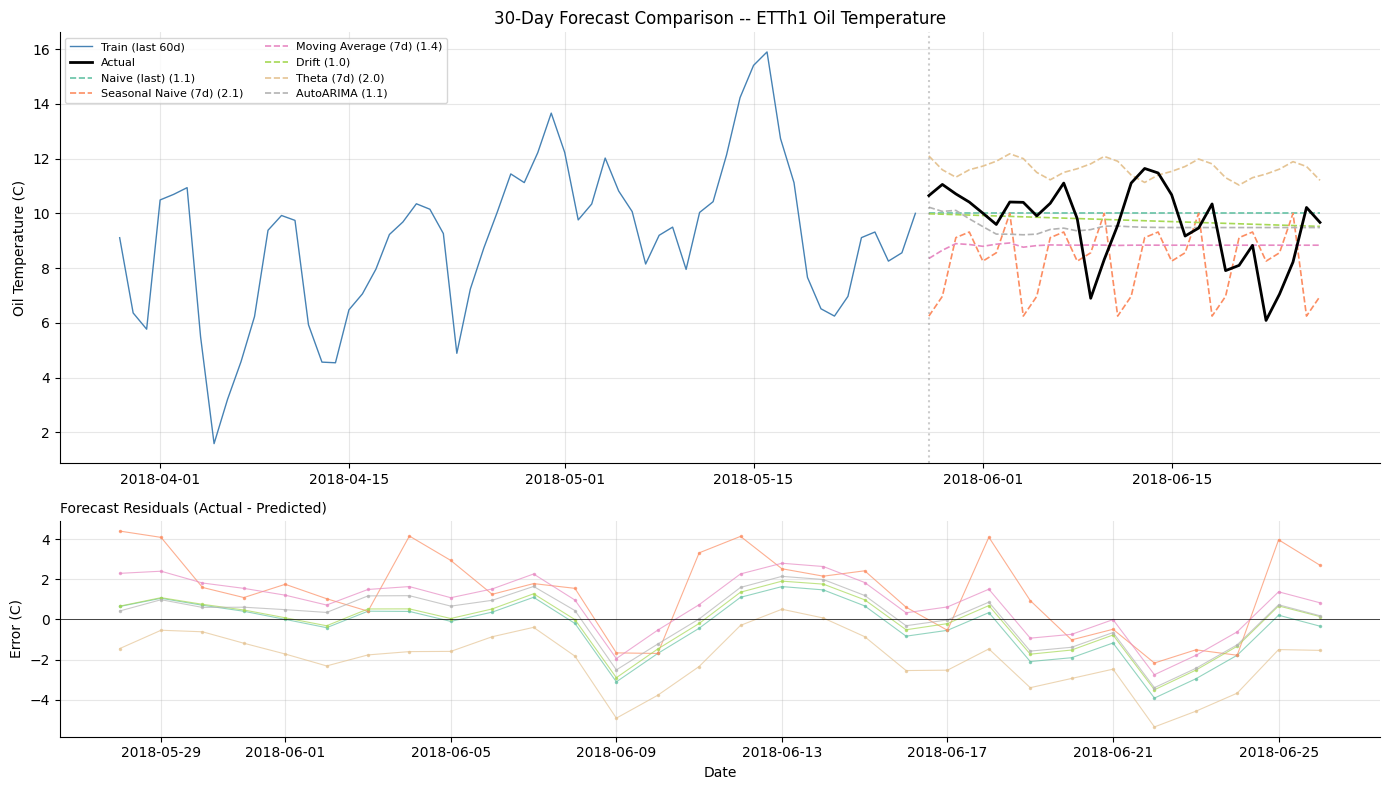

In [15]:
# Forecast comparison plot
colors = plt.cm.Set2(np.linspace(0, 1, len(forecasts)))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2, 1]})

# Top: forecasts vs actual
ax = axes[0]
# Show last 60 days of training for context
context = 60
ax.plot(dates_train[-context:], y_train[-context:], linewidth=1, color="steelblue",
        label="Train (last 60d)")
ax.plot(dates_test, y_test, linewidth=2, color="black", label="Actual", zorder=10)

for (name, pred), color in zip(forecasts.items(), colors):
    mae = np.mean(np.abs(y_test - pred))
    ax.plot(dates_test, pred, "--", linewidth=1.2, color=color, label=f"{name} ({mae:.1f})")

ax.axvline(x=dates_test[0], color="gray", linestyle=":", alpha=0.4)
ax.set_ylabel("Oil Temperature (C)")
ax.set_title("30-Day Forecast Comparison -- ETTh1 Oil Temperature", fontsize=12)
ax.legend(loc="upper left", fontsize=8, ncol=2)

# Bottom: residuals (error per day)
ax = axes[1]
for (name, pred), color in zip(forecasts.items(), colors):
    residuals = y_test - pred
    ax.plot(dates_test, residuals, ".-", linewidth=0.8, markersize=3, color=color, alpha=0.7)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_ylabel("Error (C)")
ax.set_xlabel("Date")
ax.set_title("Forecast Residuals (Actual - Predicted)", loc="left", fontsize=10)

plt.tight_layout()
plt.show()

### 2.5 Evaluation Metrics

In [16]:
from endgame.timeseries import smape

# Metrics table
results = []
for name, pred in forecasts.items():
    mae = np.mean(np.abs(y_test - pred))
    rmse = np.sqrt(np.mean((y_test - pred) ** 2))
    sm = smape(y_test, pred)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "sMAPE": sm})

results_df = pd.DataFrame(results).sort_values("MAE")
print(results_df.to_string(index=False, float_format="{:.2f}".format))

              Model  MAE  RMSE  sMAPE
              Drift 1.02  1.32  10.98
       Naive (last) 1.07  1.43  11.49
          AutoARIMA 1.10  1.35  11.89
Moving Average (7d) 1.44  1.62  15.57
         Theta (7d) 2.02  2.44  19.92
Seasonal Naive (7d) 2.13  2.45  24.38


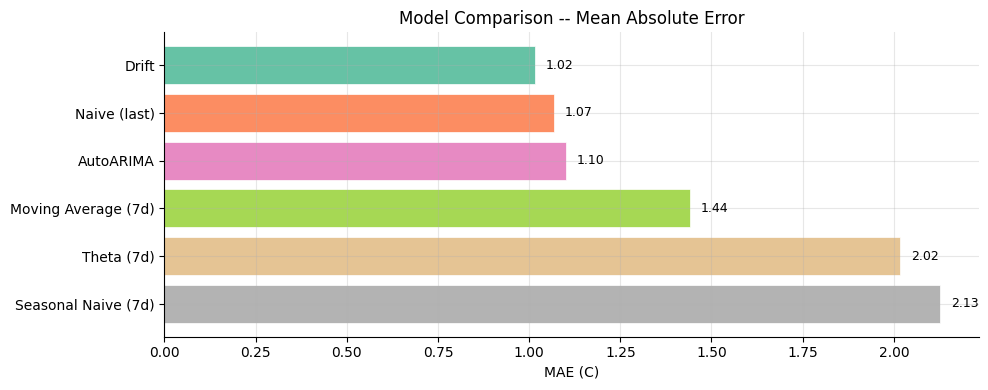

In [17]:
# Bar chart of MAE by model
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(results_df["Model"], results_df["MAE"], color=plt.cm.Set2(np.linspace(0, 1, len(results_df))),
               edgecolor="white", linewidth=0.5)
ax.set_xlabel("MAE (C)")
ax.set_title("Model Comparison -- Mean Absolute Error", fontsize=12)
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, results_df["MAE"]):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

---
## Summary

**Part 1 -- Signal Processing** (MIT-BIH ECG, 108,000 samples at 360 Hz):
- Applied clinical bandpass filtering (0.5-40 Hz) and QRS isolation (5-15 Hz)
- Visualized raw vs filtered spectra with FFT
- Generated CWT scalograms showing time-localized heartbeat energy
- Tracked permutation entropy and Higuchi FD across 30s windows

**Part 2 -- Time Series Forecasting** (ETTh1, 726 daily observations):
- Compared 6 forecasters: Naive, Seasonal Naive, Moving Average, Drift, Theta, AutoARIMA
- Evaluated with MAE, RMSE, and sMAPE on a 30-day horizon

Endgame provides **45 signal transforms** and **17 forecasters** with a
consistent sklearn-compatible API.

**Next steps:**
- Try `MiniRocketClassifier` for time series classification
- Explore `endgame.signal.connectivity` for multi-channel coherence
- Use `endgame.timeseries.validation` for time series cross-validation